# Part 3 (NumPyro-free): Filtering and the marginal log-likelihood with `dsx.condition`

This notebook is a NumPyro-free counterpart to [Part 3: Filtering and the marginal log-likelihood](03_filtering_mll.ipynb). We use **filtering** (e.g. the cuthbert particle filter) to compute the **marginal log-likelihood** (MLL) $\log p(y_{1:T} \mid \theta)$ at fixed parameters $\theta$, and show how to switch to a different filter (e.g. Taylor KF) --- all **without writing a NumPyro model**, using `dsx.condition` instead of `dsx.sample`.

## 3.1 Why filtering? Computing MLL without sampling states

Dynamical systems are a special problem in that they carry lots of structure that we can exploit in inference --- in the types of dynamical systems specified in dynestyx, observations depend only on the state (and possibly observed control inputs), and the next state depends only on the current state (and possibly observed control inputs). This suggests a family of algorithms that exploit this structure, using only the relevant information when inferring a particular state.

Additionally, sometimes we don't want to infer the full state trajectory anyways -- we only care about **parameters** $\theta$ that describe the system. The resulting problem is called **system identification**, and only necessitates the **marginal likelihood** $\log p(y_{1:T} \mid \theta)$, which implicitly marginalizes the states.

Mathematically, both of these goals are accomplished by a **filtering** algorithm; filtering algorithms exploit the structure of a dynamical system for efficient estimation, whilst also providing an estimate of the marginal likelihood. In the original notebook, dynestyx's filtering handlers add this marginal likelihood as a NumPyro factor inside a NumPyro model. Here we instead use `dsx.condition`, which runs the same filters but simply **returns** a `ConditionedResult` carrying `.marginal_loglik` (along with the filtered states), with no NumPyro model, trace, or sites involved.

We'll use the **particle filter** (from the library [`cuthbert`](https://www.github.com/state-space-models/cuthbert)) to compute a "profile likelihood": that is, we will plot the marginal log-likelihood (MLL) vs $\theta$.

### Generate synthetic data with $\rho = 0.3$

Our model definition and data generation are the same as in the original notebook, providing a linear Gaussian system with data generated at a true value of $\rho = 0.3$.

> **Note:** to keep the data (and hence the figures) identical to the original notebook, this data-generation section reuses the NumPyro-based simulator exactly as in the original. Everything from the inference sections onward is NumPyro-free.

In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

import dynestyx as dsx
from dynestyx import DiscreteTimeSimulator, DynamicalModel

# for convenience, we can define "fixed" things in the model outside of it.
# this is not required, but it helps keep the model clean.
state_dim = 2
observation_dim = 1
control_dim = 1

# Create the known matrices B, C
B = jnp.eye(state_dim, control_dim)
C = jnp.eye(observation_dim, state_dim)

# create the initial condition as a distribution
initial_condition = dist.MultivariateNormal(jnp.zeros(state_dim), jnp.eye(state_dim))


def lti_model(
    sigma_obs=0.1,
    sigma_process=0.1,
    obs_times=None,
    obs_values=None,
    ctrl_times=None,
    ctrl_values=None,
    predict_times=None,
):
    # sample the unknown parameter
    rho = numpyro.sample("rho", dist.Uniform(-0.5, 0.5))
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    # Crucially, this depends on A, which depends on rho, which is unknown.
    # Thus, the state evolution MUST be defined within `lti_model`, not outside.
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim)
    )

    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(
        C @ x, sigma_obs**2 * jnp.eye(observation_dim)
    )

    # create the dynamical model
    dynamics = DynamicalModel(
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

    # sample from the dynamical model
    return dsx.sample(
        "f",
        dynamics,
        obs_times=obs_times,
        obs_values=obs_values,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
        predict_times=predict_times,
    )

In [2]:
# create a synthetic control sequence as i.i.d. Gaussians
obs_times = jnp.arange(0.0, 100.0, 1.0)  # T=100 steps
ctrl_times = obs_times  # same times for controls
ctrl_values = jr.normal(jr.PRNGKey(0), (len(ctrl_times), control_dim))

rho_true = 0.3


def make_data(sigma_obs=0.1, sigma_process=0.1):
    predictive = Predictive(
        lti_model,
        params={"rho": jnp.array(rho_true)},
        num_samples=1,
        exclude_deterministic=False,
    )
    with DiscreteTimeSimulator():
        pred = predictive(
            rng_key=jr.PRNGKey(0),
            sigma_obs=sigma_obs,
            sigma_process=sigma_process,
            predict_times=obs_times,
            ctrl_times=ctrl_times,
            ctrl_values=ctrl_values,
        )
    print("make_data shapes:", pred["f_times"].shape, pred["f_observations"].shape)
    # Expected: f_observations has shape (1, 1, T, obs_dim)
    obs_values = pred["f_observations"][0, 0, :, :]
    return obs_times, obs_values, ctrl_times, ctrl_values


obs_times, obs_values, ctrl_times, ctrl_values = make_data(sigma_obs=0.1, sigma_process=0.1)

make_data shapes: (1, 1, 100) (1, 1, 100, 1)


**Shape convention note:** simulator outputs include a leading `n_simulations` axis (size 1 by default). Under `Predictive`, there is also a leading `num_samples` axis. In this notebook we index those axes explicitly (for example `[0, 0, ...]`) rather than applying generic squeeze helpers.

### Define the dynamics, NumPyro-free

In the original notebook, the unknown parameter $\rho$ was a latent NumPyro sample site with a uniform prior. Without NumPyro there is no notion of a prior: $\rho$ becomes a plain argument, and the model is just a factory returning a `DynamicalModel`. Note that `numpyro.distributions` objects still appear --- dynestyx uses them as plain distribution objects to describe the model; no NumPyro model, trace, or effect handlers are involved.

In [3]:
def make_dynamics(rho, sigma_obs=0.1, sigma_process=0.1):
    A = jnp.array([[0, 0.3], [rho, -0.2]])

    # create the state evolution as a callable mapping to a distribution
    state_evolution = lambda x, u, t_now, t_next: dist.MultivariateNormal(
        A @ x + B @ u, sigma_process**2 * jnp.eye(state_dim)
    )

    # create the observation model as a callable mapping to a distribution
    observation_model = lambda x, u, t: dist.MultivariateNormal(
        C @ x, sigma_obs**2 * jnp.eye(observation_dim)
    )

    return DynamicalModel(
        control_dim=control_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )

### Build the data-conditioned filter-marginalized model

To condition a model using a filtering algorithm, we use a `Filter` object, which takes a `FilterConfig` from `dynestyx.inference.filters` that specifies which filtering algorithm to use.

In this notebook, we'll compare several available options: the ensemble Kalman filter (EnKF, well-suited for non-linear Gaussian models and used by default), the particle filter (PF, more computationally expensive but fully general), and the extended Kalman filter (EKF, less accurate for strongly non-linear systems, but efficient and optimal for linear-Gaussian models).

Next, we'll build a function that evaluates and returns the MLL at a fixed value of the parameter $\rho$, conditioned on data, and use it to plot a *likelihood profile*. Instead of evaluating a NumPyro model with `Predictive` and reading the MLL factor from the trace, we call `dsx.condition` inside the `Filter` handler and read `.marginal_loglik` off the returned `ConditionedResult`.

In [4]:
from dynestyx import Filter
from dynestyx.inference.filters import EnKFConfig, EKFConfig, PFConfig

def get_mll(rho, filter_config):
    """Run the filter via dsx.condition and return the MLL from the ConditionedResult."""

    with Filter(filter_config):
        result = dsx.condition(
            "f",
            make_dynamics(rho),
            obs_times=obs_times,
            obs_values=obs_values,
            ctrl_times=ctrl_times,
            ctrl_values=ctrl_values,
        )

    return result.marginal_loglik


get_mll(0.3, EKFConfig())

Array(30.354883, dtype=float32)

Since dynestyx and its dependencies are written in `jax`, we can exploit its tools for efficient inference (such as jit-compiling or vectorization). In this case, we will generate the likelihood profiles by vmapping over different values of $\rho$.

One difference from the original notebook: outside a NumPyro model there is no seed handler to supply PRNG keys, so the stochastic filters (EnKF, PF) need an explicit `crn_seed` in their config. Using a fixed key across all values of $\rho$ gives common random numbers, just like the fixed `Predictive` key in the original.

In [5]:
from jax import vmap

# Profile over values of rho, keeping other parameters at their true values:
rho_grid = jnp.linspace(-0.8, 0.8, 50)

mll_enkf = vmap(lambda p: get_mll(p, filter_config=EnKFConfig(n_particles=100, crn_seed=jr.PRNGKey(0))))(rho_grid)
mll_kf = vmap(lambda p: get_mll(p, filter_config=EKFConfig()))(rho_grid)
mll_pf = vmap(lambda p: get_mll(p, filter_config=PFConfig(n_particles=1000, crn_seed=jr.PRNGKey(0))))(rho_grid)

We now plot the likelihood profiles, which should be at a maximum at or near the true data-generating value $\rho = 0.3$.

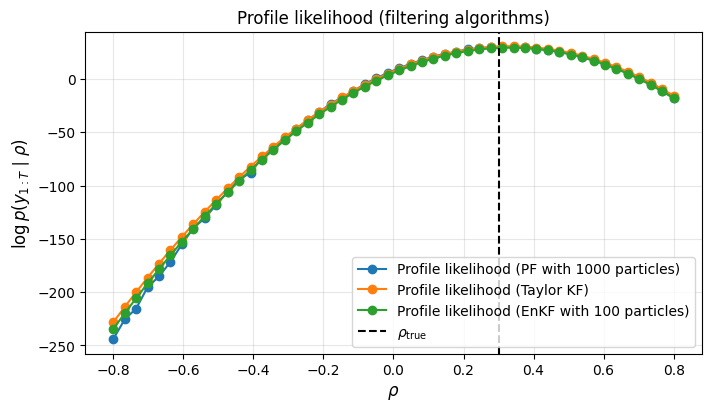

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.plot(rho_grid, mll_pf, "o-", color="C0", label="Profile likelihood (PF with 1000 particles)")
ax.plot(rho_grid, mll_kf, "o-", color="C1", label="Profile likelihood (Taylor KF)")
ax.plot(rho_grid, mll_enkf, "o-", color="C2", label="Profile likelihood (EnKF with 100 particles)")
ax.axvline(rho_true, color="k", linestyle="--", label=r"$\rho_{\mathrm{true}}$")
ax.set_xlabel(r"$\rho$", fontsize=12)
ax.set_ylabel(r"$\log p(y_{1:T} \mid \rho)$", fontsize=12)
ax.set_title("Profile likelihood (filtering algorithms)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

We additionally note that for non-Bayesian analysis --- for example, obtaining a maximum likelihood estimate of the system's parameters --- you can consider the filter-based MLL as a "loss function" and proceed from there with learning dynamical systems from data. This is exactly what we do in the NumPyro-free counterpart of Part 5: [MLE via filtering + optax](05_svi_no_numpyro.ipynb).

For posterior inference over unknown parameters with these likelihood approximations, see the original NumPyro-based tutorials, e.g. [Part 4 --- Filtering + NUTS: pseudomarginal inference](04_filtering_nuts_pseudomarginal.ipynb).